## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42


## 2. Load data

Reads `huntingtons_ML_dataset_GSE64810.csv` — the RNA-seq (GSE64810) version of the
dataset, built from DESeq2-normalized counts rather than microarray probes.

Column layout:
- `Sample_ID` — e.g. `C_0002`, `H_0001` (identifier column, dropped from features)
- `Huntingtons_Disease` — target column (1 = HD, 0 = control)
- 12 gene-symbol columns — one column per biomarker (already gene-level, no probe
  averaging needed here, unlike the GSE3790 microarray dataset).

In [2]:
DATA_PATH = "../datasets/GSE64810_Huntington_dataset.csv"
ID_COL = "Sample_ID"
TARGET_COL = "Huntingtons_Disease"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(69, 12)


,Sample_ID,Huntingtons_Disease,TUT7,PPP1CC,CEBPB,FTO,METTL16,IGF2BP3,YTHDF1,YTHDF3,YTHDC1,YTHDC2
0,C_0002,0,325.449882,2526.205485,883.080472,882.088247,443.524686,0.992225,1621.296057,1347.441888,1842.562288,1131.136784
1,C_0003,0,410.441330,2518.166614,675.146246,1102.441447,705.879775,0.000000,1858.882835,1126.235147,2830.458930,868.470061
2,C_0004,0,393.815608,2446.219871,567.411909,1443.329243,403.735396,2.975937,1574.270453,1345.123336,1958.166272,1101.096536
3,C_0005,0,430.171717,2484.885934,1114.085277,2500.744800,470.810059,2.973537,2470.018248,1415.403715,1926.852117,1391.615418
4,C_0006,0,424.394106,2277.647809,459.099232,1622.216724,499.753808,1.983150,1584.536874,1541.899148,2282.605684,1280.123344


In [3]:
feature_cols = [c for c in df.columns if c not in (ID_COL, TARGET_COL)]

X = df[feature_cols]
y = df[TARGET_COL]

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print("Features:", feature_cols)
print("\nClass balance:")
print(y.value_counts())


Samples: 69, Features: 10
Features: ['TUT7', 'PPP1CC', 'CEBPB', 'FTO', 'METTL16', 'IGF2BP3', 'YTHDF1', 'YTHDF3', 'YTHDC1', 'YTHDC2']

Class balance:
Huntingtons_Disease
0    49
1    20
Name: count, dtype: int64


## 3. Impute + scale

In [4]:
X_imputed = SimpleImputer(strategy="mean").fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imputed)


## 4. Train/test split

Stratified so both classes are represented in the test set. GSE64810 has a much
better class balance (~20 HD vs ~49 control) than the GSE3790 microarray subset,
so a held-out split is more reliable here — but still check the printed class
counts below before trusting the results.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train class balance:")
print(y_train.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())


Train class balance:
Huntingtons_Disease
0    39
1    16
Name: count, dtype: int64

Test class balance:
Huntingtons_Disease
0    10
1     4
Name: count, dtype: int64


## 5. Models + hyperparameter grids

In [6]:
models = {
    "SVM": {
        "model": SVC(probability=True, random_state=RANDOM_STATE),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
        },
    },
    "GLM": {
        "model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "params": {
            "C": [0.1, 1, 10],
            "penalty": ["l2"],
        },
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 300, 400],
            "max_depth": [1 ,2 , 3, 5],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
        ),
        "params": {
            "n_estimators": [100, 200, 400],
            "max_depth": [2, 3, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1.0],
        },
    },
}


## 6. GridSearchCV for each model

Uses `StratifiedKFold` so class balance is preserved in every fold.
`n_splits` is capped at the smallest class count in the training set so
GridSearchCV doesn't fail on a fold with zero positive examples.

In [7]:
best_models = {}
roc_data = {}

min_class_count = y_train.value_counts().min()
print(f"Min class split {min_class_count}")
n_splits = max(2, min(5, min_class_count))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
print(f"Using {n_splits}-fold StratifiedKFold for GridSearchCV")


Min class split 16
Using 5-fold StratifiedKFold for GridSearchCV


In [8]:
for name, mp in models.items():
    clf = GridSearchCV(
        mp["model"], mp["params"], cv=cv, scoring="roc_auc", n_jobs=-1
    )
    clf.fit(X_train, y_train)

    best_models[name] = clf.best_estimator_

    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"Best {name} params: {clf.best_params_}")
    print(f"  CV best ROC-AUC: {clf.best_score_:.4f}  |  Test ROC-AUC: {roc_auc:.4f}")


Best SVM params: {'C': 10, 'kernel': 'rbf'}
  CV best ROC-AUC: 0.9345  |  Test ROC-AUC: 0.9500


/home/cfg4040b/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/cfg4040b/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/cfg4040b/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To 

Best GLM params: {'C': 10, 'penalty': 'l2'}
  CV best ROC-AUC: 0.9012  |  Test ROC-AUC: 0.9500
Best RandomForest params: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  CV best ROC-AUC: 0.9381  |  Test ROC-AUC: 0.9500
Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 1.0}
  CV best ROC-AUC: 0.9262  |  Test ROC-AUC: 0.9000


## 7. ROC curve comparison

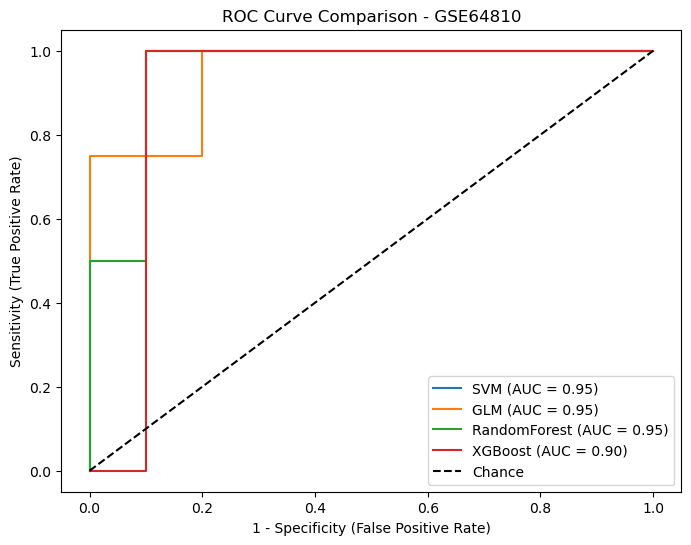

In [9]:
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("ROC Curve Comparison - GSE64810")
plt.legend(loc="lower right")
plt.show()


## 8. Detailed evaluation per model

Accuracy, confusion matrix, and classification report for each tuned model
on the held-out test set.

EVALUATION: SVM
Accuracy: 0.8571
True Negatives (TN): 9
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP): 3

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.75      0.75      0.75         4

    accuracy                           0.86        14
   macro avg       0.82      0.82      0.82        14
weighted avg       0.86      0.86      0.86        14



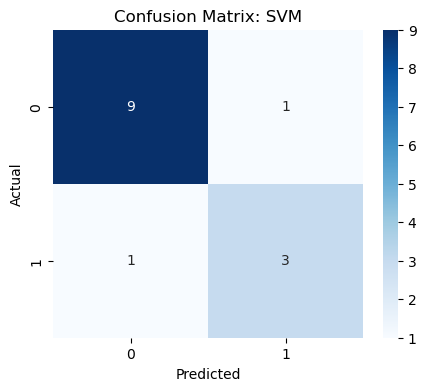

EVALUATION: GLM
Accuracy: 0.8571
True Negatives (TN): 8
False Positives (FP): 2
False Negatives (FN): 0
True Positives (TP): 4

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.67      1.00      0.80         4

    accuracy                           0.86        14
   macro avg       0.83      0.90      0.84        14
weighted avg       0.90      0.86      0.86        14



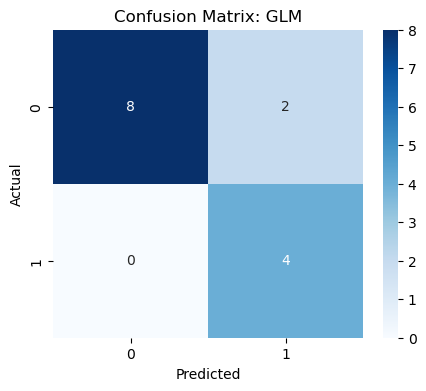

EVALUATION: RandomForest
Accuracy: 0.8571
True Negatives (TN): 9
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP): 3

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.75      0.75      0.75         4

    accuracy                           0.86        14
   macro avg       0.82      0.82      0.82        14
weighted avg       0.86      0.86      0.86        14



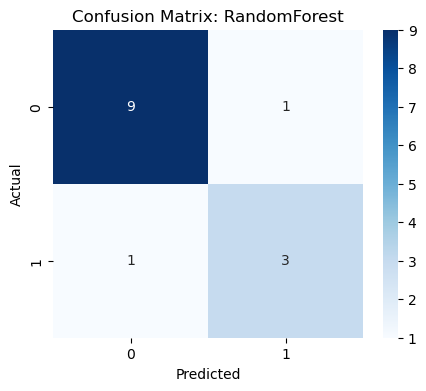

EVALUATION: XGBoost
Accuracy: 0.8571
True Negatives (TN): 9
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP): 3

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.75      0.75      0.75         4

    accuracy                           0.86        14
   macro avg       0.82      0.82      0.82        14
weighted avg       0.86      0.86      0.86        14



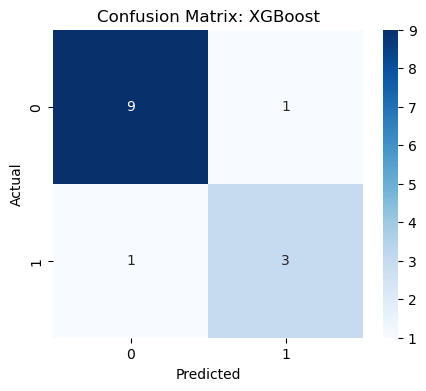

In [10]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"{'='*20}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


for name, model in best_models.items():
    evaluate_model(model, X_test, y_test, name)


## 9. Feature importance (RandomForest & XGBoost)

Which of the 12 m6A biomarkers are actually driving predictions in this
RNA-seq cohort.

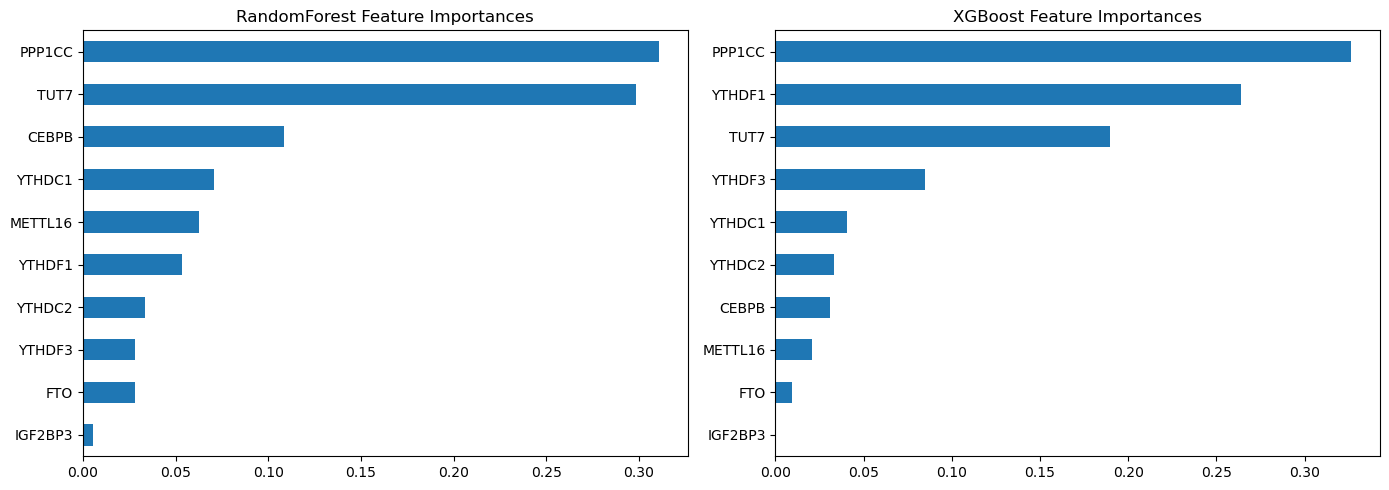

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["RandomForest", "XGBoost"]):
    model = best_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind="barh", ax=ax)
    ax.set_title(f"{name} Feature Importances")

plt.tight_layout()
plt.show()


In [12]:
with open(DATA_PATH, encoding="utf-8") as f:
    for line in f:
        if line.startswith("ENSG00000221869") or line.startswith("ENSG00000198492"):
            print(line[:100])

print("Search complete.")


Search complete.


## 10. Per-gene ROC curves (individually trained single-feature models)

For each of the 10 available biomarker genes, a **separate Logistic Regression
model is trained using only that one gene as its input feature**. Predictions
are made using `cross_val_predict` with the same `StratifiedKFold` scheme used
for the multivariate models in Section 6, so every sample gets an out-of-fold
predicted probability (i.e. the model never sees a sample's own label when
predicting it) — this is a real trained-model ROC curve per gene, not just a
raw-value threshold sweep.

In [13]:
from sklearn.model_selection import cross_val_predict

gene_roc_data = {}
gene_models = {}

gene_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

for gene in feature_cols:
    # Single-feature input: reshape to (n_samples, 1)
    gene_X = X[[gene]].values
    gene_X_imputed = SimpleImputer(strategy="mean").fit_transform(gene_X)
    gene_X_scaled = StandardScaler().fit_transform(gene_X_imputed)

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

    # Out-of-fold predicted probabilities: each sample's prediction comes from
    # a model that was NOT trained on that sample
    y_prob = cross_val_predict(
        model, gene_X_scaled, y, cv=gene_cv, method="predict_proba"
    )[:, 1]

    fpr, tpr, _ = roc_curve(y, y_prob)
    gene_auc = auc(fpr, tpr)
    gene_roc_data[gene] = (fpr, tpr, gene_auc)

    # Also fit on the full data for reference (e.g. if you want coefficients later)
    gene_models[gene] = model.fit(gene_X_scaled, y)

# Sort genes by AUC (distance from 0.5, since a gene could be predictive in
# either direction depending on whether it's up- or down-regulated in HD)
gene_roc_data = dict(
    sorted(gene_roc_data.items(), key=lambda kv: abs(kv[1][2] - 0.5), reverse=True)
)

print("Per-gene AUC (individually trained single-feature Logistic Regression, cross-validated):")
for gene, (_, _, gene_auc) in gene_roc_data.items():
    print(f"  {gene}: AUC = {gene_auc:.3f}")


Per-gene AUC (individually trained single-feature Logistic Regression, cross-validated):
  PPP1CC: AUC = 0.860
  TUT7: AUC = 0.849
  CEBPB: AUC = 0.664
  METTL16: AUC = 0.663
  YTHDC1: AUC = 0.658
  YTHDF1: AUC = 0.654
  IGF2BP3: AUC = 0.428
  FTO: AUC = 0.544
  YTHDF3: AUC = 0.543
  YTHDC2: AUC = 0.504


### 10a. All genes overlaid on one plot

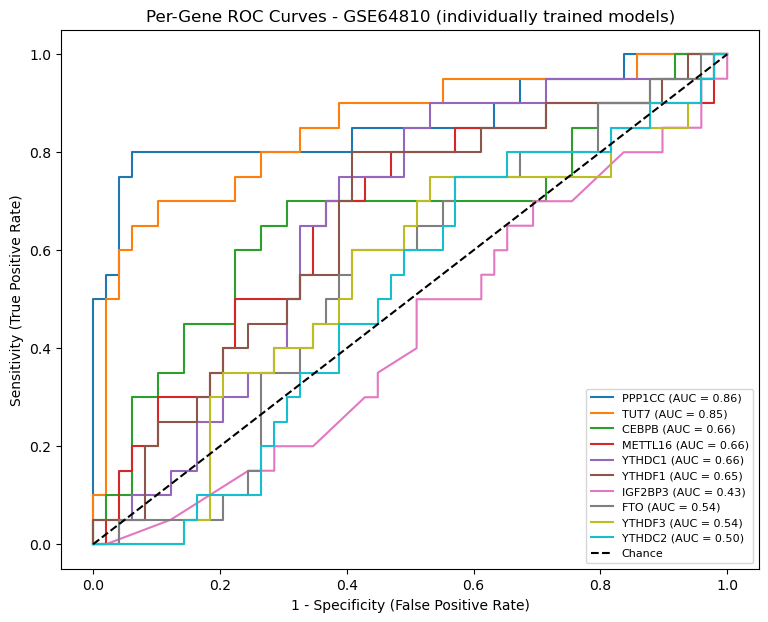

In [14]:
plt.figure(figsize=(9, 7))
for gene, (fpr, tpr, gene_auc) in gene_roc_data.items():
    plt.plot(fpr, tpr, label=f"{gene} (AUC = {gene_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("Per-Gene ROC Curves - GSE64810 (individually trained models)")
plt.legend(loc="lower right", fontsize=8)
plt.show()


### 10b. Individual small-multiple panels (one subplot per gene)

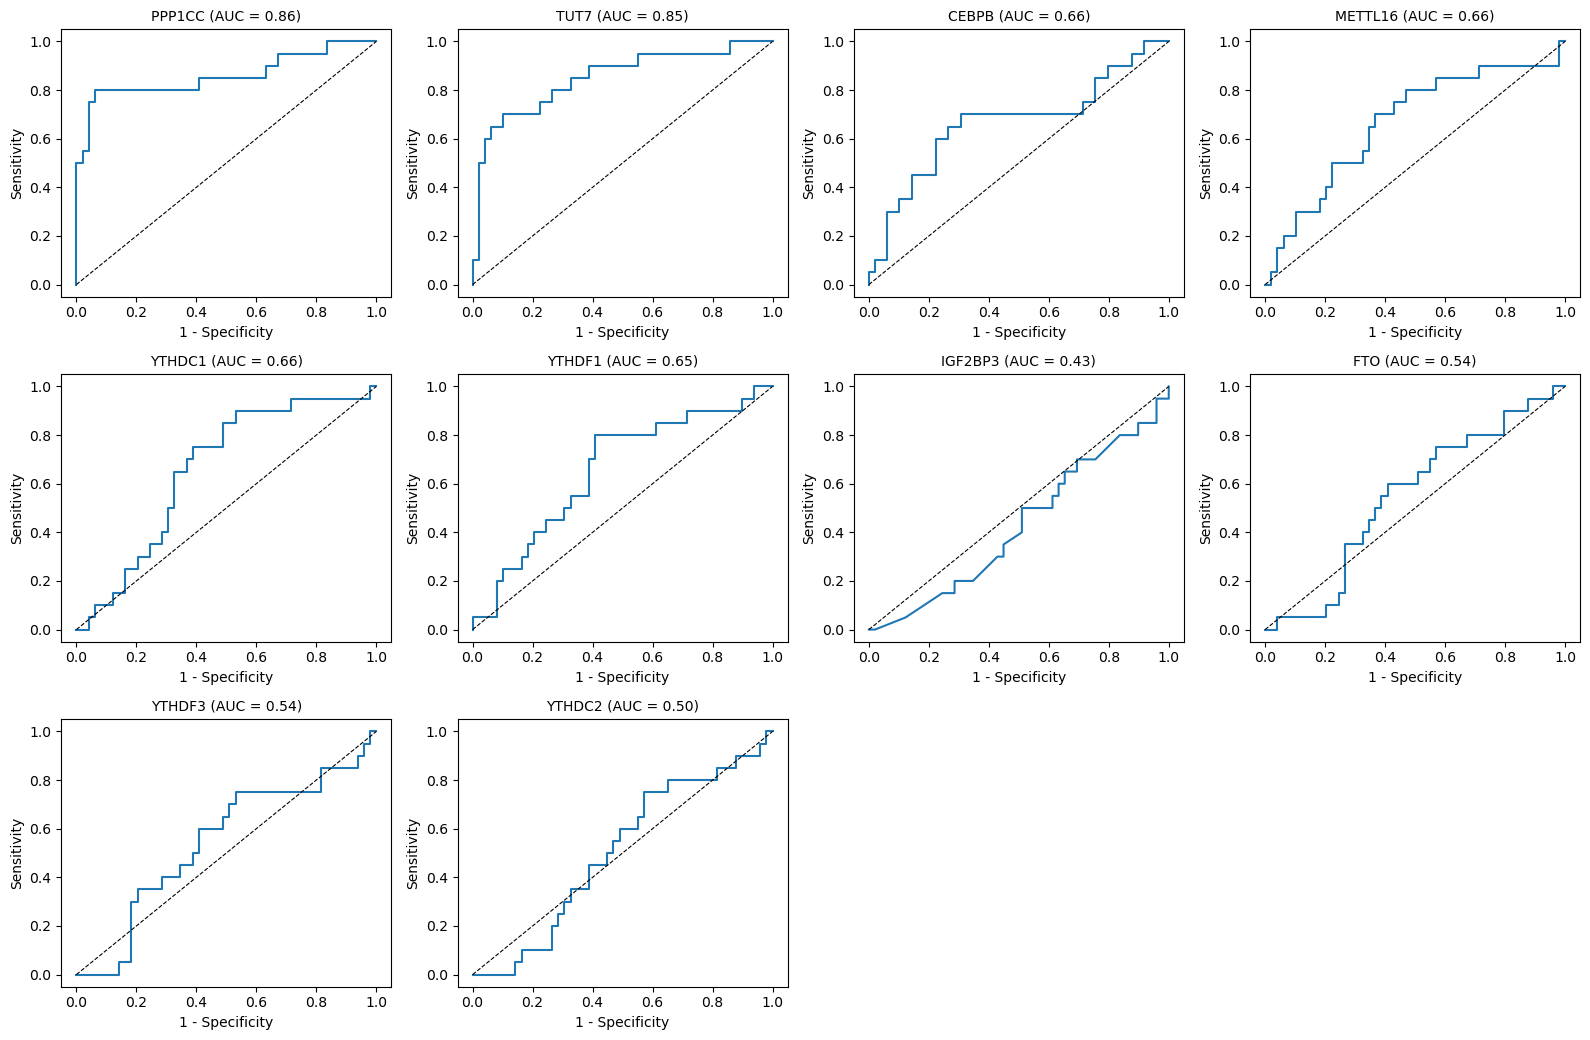

In [15]:
n_genes = len(gene_roc_data)
n_cols = 4
n_rows = -(-n_genes // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, (gene, (fpr, tpr, gene_auc)) in zip(axes, gene_roc_data.items()):
    ax.plot(fpr, tpr, color="tab:blue")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_title(f"{gene} (AUC = {gene_auc:.2f})", fontsize=10)
    ax.set_xlabel("1 - Specificity")
    ax.set_ylabel("Sensitivity")

# Hide any unused subplot axes
for ax in axes[n_genes:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
